# Evaluation — Counselor Models on Both Datasets (metrics + comparison)

Scores every fine-tuned adapter on **its own dataset's held-out test split**, next to the **un-tuned base model** on the same split, then charts each metric as **models × score, one bar per dataset**.

| Item | Detail |
|------|--------|
| **Systems** | 3 model families (gemma2 · llama32 · qwen3) × {tuned adapter, untuned base} × 2 datasets → 12 generation passes |
| **Test sets** | `amod`: 244 rows grouped to unique questions, **multi-reference** scoring · `mentalchat16k`: full 1,597 rows (same grouping code) |
| **Metrics** | BERTScore F1 · corpus BLEU (smoothing m1) · ROUGE-L (multi-ref = max over refs) · Flesch Reading Ease · Flesch-Kincaid Grade |
| **Generation** | greedy, `max_new_tokens=200`, batch 8, left padding, per-model end-of-turn stop tokens |
| **Caching** | each pass saves `results/predictions/<dataset>_<model>_<variant>.jsonl` and is skipped on re-run — interruption-safe |
| **Outputs** | `results/scores.csv` · charts (`results/*.png`) · `results/eval_report.md` |

**Before running:** close training kernels (needs ~7.6 GB VRAM free). Run order: the amod passes are quick (~1 h); the mentalchat16k passes are several hours — start the notebook and leave it (caching means you can stop/resume). Missing adapters are skipped with a warning, so this can run before all 6 trainings are done.

⚠ Note on comparing datasets: raw reference-based scores from two *different* test sets are not perfectly comparable (reference style and length differ). The tuned-vs-base Δ per dataset (computed on the *same* test set) is the fairer cross-dataset signal — both views are in the report.

In [1]:
# Cell 1 — Setup: imports, compat patch, adapter detection
import os
os.environ["PYTHONUTF8"] = "1"
os.environ["BNB_CUDA_VERSION"] = "130"  # torch is cu132; bitsandbytes 0.49.2 tops out at cu130

import gc
import json
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import textstat
import torch
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from bert_score import score as bert_score_fn
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel

import ft_utils

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

# --- bert_score / transformers compat patch (carried over from the prior study) ---
# The fast tokenizer backend dropped `build_inputs_with_special_tokens`;
# monkey-patching it back prevents an AttributeError on 2nd+ BERTScore calls.
try:
    import transformers.tokenization_utils_tokenizers as _tut
    if not hasattr(_tut.TokenizersBackend, "build_inputs_with_special_tokens"):
        def _build_inputs_with_special_tokens(self, token_ids_0, token_ids_1=None):
            output = [self.cls_token_id] + token_ids_0 + [self.sep_token_id]
            if token_ids_1 is not None:
                output += [self.sep_token_id] + token_ids_1 + [self.sep_token_id]
            return output
        _tut.TokenizersBackend.build_inputs_with_special_tokens = _build_inputs_with_special_tokens
        print("Patched TokenizersBackend.build_inputs_with_special_tokens")
except ImportError:
    pass  # module renamed/absent in this transformers version; patch not needed

MODELS = list(ft_utils.CFG["models"])          # gemma2, llama32, qwen3
DATASETS = list(ft_utils.CFG["datasets"])      # mentalchat16k
TCFG = ft_utils.CFG["training"]

RESULTS_DIR = ft_utils.RESULTS_ROOT
PRED_DIR = RESULTS_DIR / "predictions"
PRED_DIR.mkdir(parents=True, exist_ok=True)

print(f"CUDA: {torch.cuda.is_available()} | free VRAM: "
      f"{(torch.cuda.mem_get_info()[0] / 1e9 if torch.cuda.is_available() else 0):.1f} GB")
print("\nAdapters found:")
AVAILABLE = {}
for ds in DATASETS:
    for mk in MODELS:
        path = ft_utils.MODELS_ROOT / ds / mk
        ok = (path / "adapter_config.json").exists()
        AVAILABLE[(ds, mk)] = ok
        print(f"  {ds}/{mk}: {'OK' if ok else 'MISSING - tuned pass will be skipped'}")

Patched TokenizersBackend.build_inputs_with_special_tokens
CUDA: True | free VRAM: 7.4 GB

Adapters found:
  amod/gemma2: OK
  amod/llama32: OK
  amod/qwen3: OK
  mentalchat16k/gemma2: OK
  mentalchat16k/llama32: OK
  mentalchat16k/qwen3: OK


In [2]:
# Cell 2 — Helpers: cleaning, generation, grouping, metrics, model loading

# Markers that end an assistant turn (cut generation here) and markers that
# start a new turn (base models often keep "chatting" — cut there too).
_END_MARKERS = ["<end_of_turn>", "<|eot_id|>", "<|im_end|>",
                "<|endoftext|>", "<|end_of_text|>", "<eos>"]
_TURN_MARKERS = ["<start_of_turn>", "<|start_header_id|>", "<|im_start|>", "<bos>"]
_LEFTOVER_TOKENS = _END_MARKERS + _TURN_MARKERS + ["/no_think"]


def clean_output(text):
    """Cut the decoded continuation at the first end-of-turn / new-turn marker,
    strip leftover template tokens and Qwen <think> blocks."""
    for marker in _END_MARKERS + _TURN_MARKERS:
        idx = text.find(marker)
        if idx != -1:
            text = text[:idx]
    text = re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL)
    text = re.sub(r"<think>.*", "", text, flags=re.DOTALL)  # unclosed think block
    for tok in _LEFTOVER_TOKENS:
        text = text.replace(tok, "")
    return text.strip()


def _stop_token_ids(tokenizer, model_key):
    """eos ids: the tokenizer's own EOS + this model's end-of-turn token."""
    end_tok = {"gemma2": "<end_of_turn>", "llama32": "<|eot_id|>", "qwen3": "<|im_end|>"}[model_key]
    ids = {tokenizer.eos_token_id}
    tid = tokenizer.convert_tokens_to_ids(end_tok)
    if tid is not None and tid >= 0:
        ids.add(tid)
    return [i for i in ids if i is not None]


def generate_predictions(model, tokenizer, inputs_list, model_key,
                         max_new_tokens=200, batch_size=8):
    """Batched greedy generation (ported from the prior study's evaluate.ipynb).
    Decodes WITHOUT skipping special tokens so clean_output can cut at the
    first end-of-turn marker (base models don't stop on their own)."""
    model.eval()
    tokenizer.padding_side = "left"
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    prompt_fn = ft_utils.PROMPT_FORMATTERS[model_key]
    stop_ids = _stop_token_ids(tokenizer, model_key)
    predictions = []
    for i in range(0, len(inputs_list), batch_size):
        prompts = [prompt_fn(x) for x in inputs_list[i:i + batch_size]]
        # add_special_tokens=False: templates already carry BOS (matches TRL training)
        encoded = tokenizer(prompts, return_tensors="pt", padding=True, truncation=True,
                            max_length=TCFG["max_seq_length"], add_special_tokens=False).to(model.device)
        with torch.no_grad():
            output_ids = model.generate(
                **encoded,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                eos_token_id=stop_ids,
                pad_token_id=tokenizer.pad_token_id,
            )
        prompt_len = encoded["input_ids"].shape[1]
        for out in output_ids:
            decoded = tokenizer.decode(out[prompt_len:], skip_special_tokens=False)
            predictions.append(clean_output(decoded))
        done = min(i + batch_size, len(inputs_list))
        print(f"    {done}/{len(inputs_list)}", end="\r")
    print(f"    {len(inputs_list)}/{len(inputs_list)} done")
    return predictions


def group_test_set(test_df):
    """Group by unique user text; collect ALL reference answers per question.
    amod repeats the same question with different therapist answers, so we
    generate once per question and score multi-reference. mentalchat16k goes
    through the same code (~99% singleton groups)."""
    grouped = (test_df.groupby("input", sort=True)["output"].apply(list)
               .reset_index().rename(columns={"output": "refs"}))
    return grouped


def compute_metrics(predictions, reference_lists, bert_kwargs=None):
    """Multi-reference metric suite (same metrics as the prior study).
    BLEU is natively multi-ref; ROUGE-L and BERTScore take the best reference."""
    bert_kwargs = bert_kwargs or {"lang": "en"}

    # BERTScore F1 — bert_score natively supports a list of refs per candidate
    _, _, F1 = bert_score_fn(predictions, reference_lists, verbose=False, **bert_kwargs)
    bertscore_f1 = F1.mean().item()

    # corpus BLEU with multi-references
    smooth = SmoothingFunction().method1
    refs_tok = [[nltk.word_tokenize(r) for r in refs] for refs in reference_lists]
    preds_tok = [nltk.word_tokenize(p) for p in predictions]
    bleu = corpus_bleu(refs_tok, preds_tok, smoothing_function=smooth)

    # ROUGE-L: best f-measure over the references of each question
    scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)
    rouge_l = np.mean([
        max(scorer.score(ref, pred)["rougeL"].fmeasure for ref in refs)
        for pred, refs in zip(predictions, reference_lists)
    ])

    # Readability on predictions (reference-free)
    fre, fkg = [], []
    for pred in predictions:
        if pred and pred.strip():
            try:
                fre.append(textstat.flesch_reading_ease(pred))
                fkg.append(textstat.flesch_kincaid_grade(pred))
            except Exception:
                pass
    return {
        "bertscore_f1": round(bertscore_f1, 4),
        "bleu": round(bleu, 4),
        "rouge_l": round(float(rouge_l), 4),
        "flesch_reading_ease": round(float(np.mean(fre)) if fre else 0.0, 2),
        "flesch_kincaid_grade": round(float(np.mean(fkg)) if fkg else 0.0, 2),
    }


def load_system(model_key, dataset_key, variant):
    """4-bit base model; 'tuned' attaches the LoRA adapter for that dataset.
    Quant config and eager-attn flag come from config.yaml (as in training)."""
    mcfg = ft_utils.CFG["models"][model_key]
    qcfg = TCFG["quant"]
    kwargs = dict(
        quantization_config=BitsAndBytesConfig(
            load_in_4bit=qcfg["load_in_4bit"],
            bnb_4bit_quant_type=qcfg["bnb_4bit_quant_type"],
            bnb_4bit_compute_dtype=getattr(torch, qcfg["bnb_4bit_compute_dtype"]),
            bnb_4bit_use_double_quant=qcfg["bnb_4bit_use_double_quant"],
        ),
        device_map="auto",
        dtype=torch.bfloat16,
    )
    if mcfg.get("attn_implementation"):
        kwargs["attn_implementation"] = mcfg["attn_implementation"]

    model = AutoModelForCausalLM.from_pretrained(mcfg["instruct_id"], **kwargs)
    if variant == "tuned":
        adapter = ft_utils.MODELS_ROOT / dataset_key / model_key
        model = PeftModel.from_pretrained(model, str(adapter))
        tokenizer = AutoTokenizer.from_pretrained(str(adapter))
    else:
        tokenizer = AutoTokenizer.from_pretrained(mcfg["instruct_id"])
    model.eval()
    model.config.use_cache = True
    return model, tokenizer

In [3]:
# Cell 3 — Build the two test beds (grouped, multi-reference)
TESTBEDS = {}
for ds in DATASETS:
    _, _, test_df = ft_utils.load_and_split(ds)
    grouped = group_test_set(test_df)
    TESTBEDS[ds] = grouped
    n_multi = (grouped["refs"].str.len() > 1).sum()
    print(f"{ds}: {len(test_df)} test rows -> {len(grouped)} unique questions "
          f"({n_multi} with multiple references, max {grouped['refs'].str.len().max()})")

amod: 244 test rows -> 71 unique questions (34 with multiple references, max 38)
mentalchat16k: 1597 test rows -> 1591 unique questions (3 with multiple references, max 3)


In [4]:
# Cell 4 — Generation passes (cached; safe to interrupt and re-run)
# Each pass: load model -> generate over the test bed -> save jsonl -> free VRAM.
PASSES = [(ds, mk, variant)
          for ds in DATASETS
          for mk in MODELS
          for variant in ("tuned", "base")]

for ds, mk, variant in PASSES:
    pred_path = PRED_DIR / f"{ds}_{mk}_{variant}.jsonl"
    if pred_path.exists():
        print(f"[cached]  {pred_path.name}")
        continue
    if variant == "tuned" and not AVAILABLE[(ds, mk)]:
        print(f"[skipped] {pred_path.name} — adapter not trained yet")
        continue

    print(f"[running] {pred_path.name}")
    start = time.time()
    model, tokenizer = load_system(mk, ds, variant)
    inputs_list = TESTBEDS[ds]["input"].tolist()
    preds = generate_predictions(model, tokenizer, inputs_list, mk)

    # Free the model BEFORE the next pass loads. The del must happen in THIS
    # scope — handing the objects to a helper keeps our references alive and
    # nothing would actually be released.
    del model, tokenizer
    gc.collect()
    torch.cuda.empty_cache()
    print(f"          VRAM free again: {torch.cuda.mem_get_info()[0] / 1e9:.1f} GB")

    with open(pred_path, "w", encoding="utf-8") as f:
        for inp, pred in zip(inputs_list, preds):
            f.write(json.dumps({"input": inp, "prediction": pred}, ensure_ascii=False) + "\n")
    print(f"          done in {(time.time() - start) / 60:.1f} min -> {pred_path.name}")

[running] amod_gemma2_tuned.jsonl


This can be used to load a bitsandbytes version built with a CUDA version that is different from the PyTorch CUDA version.
If this was unintended set the BNB_CUDA_VERSION variable to an empty string: export BNB_CUDA_VERSION=

W0723 21:29:57.160000 20196 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

c:\Users\laoli\OneDrive\Desktop\MultiAgent2\.venv\Lib\site-packages\bitsandbytes\backends\cuda\ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


    71/71 done
          VRAM free again: 7.2 GB
          done in 4.8 min -> amod_gemma2_tuned.jsonl
[running] amod_gemma2_base.jsonl


...

    1591/1591 done
          VRAM free again: 7.2 GB
          done in 32.4 min -> mentalchat16k_llama32_base.jsonl
[running] mentalchat16k_qwen3_tuned.jsonl


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

    1591/1591 done
          VRAM free again: 7.2 GB
          done in 96.6 min -> mentalchat16k_qwen3_tuned.jsonl
[running] mentalchat16k_qwen3_base.jsonl


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

    1591/1591 done
          VRAM free again: 7.2 GB
          done in 63.4 min -> mentalchat16k_qwen3_base.jsonl


In [5]:
# Cell 5 — Score every cached prediction file -> results/scores.csv
# (BERTScore's scoring model loads AFTER all LLM passes, so VRAM is free.)
RESCORE = False  # set True to recompute metrics even if scores.csv exists

scores_path = RESULTS_DIR / "scores.csv"
if scores_path.exists() and not RESCORE:
    scores = pd.read_csv(scores_path)
    print(f"Loaded cached {scores_path.name} — set RESCORE=True to recompute")
else:
    rows = []
    for ds, mk, variant in PASSES:
        pred_path = PRED_DIR / f"{ds}_{mk}_{variant}.jsonl"
        if not pred_path.exists():
            continue
        with open(pred_path, encoding="utf-8") as f:
            records = [json.loads(line) for line in f]
        pred_by_input = {r["input"]: r["prediction"] for r in records}
        grouped = TESTBEDS[ds]
        mask = grouped["input"].isin(pred_by_input)
        if not mask.all():
            print(f"  ! {pred_path.name}: {(~mask).sum()} test questions missing from cache")
        preds = [pred_by_input[i] for i in grouped.loc[mask, "input"]]
        refs = grouped.loc[mask, "refs"].tolist()

        print(f"Scoring {pred_path.name} ({len(preds)} predictions)...")
        metrics = compute_metrics(preds, refs)
        rows.append({"model": mk, "dataset": ds, "variant": variant, "n": len(preds), **metrics})

    scores = pd.DataFrame(rows)
    scores.to_csv(scores_path, index=False)
    print(f"\nSaved {scores_path}")
scores

Scoring amod_gemma2_tuned.jsonl (71 predictions)...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Scoring amod_gemma2_base.jsonl (71 predictions)...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

...

Scoring mentalchat16k_qwen3_base.jsonl (1591 predictions)...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Saved C:\Users\laoli\OneDrive\Desktop\MultiAgent2\fine_tuning_chatbot\results\scores.csv


,model,dataset,variant,n,bertscore_f1,bleu,rouge_l,flesch_reading_ease,flesch_kincaid_grade
0,gemma2,amod,tuned,71,0.8020,0.0109,0.1071,75.78,6.85
1,gemma2,amod,base,71,0.7977,0.0179,0.1278,77.85,4.85
2,llama32,amod,tuned,71,0.7884,0.0077,0.0752,30.83,16.23
3,llama32,amod,base,71,0.7896,0.0107,0.0965,53.98,8.47
4,qwen3,amod,tuned,71,0.7349,0.0036,0.0929,68.83,8.81
5,qwen3,amod,base,71,0.8475,0.0390,0.1650,68.34,7.67
6,gemma2,mentalchat16k,tuned,1591,0.8299,0.0231,0.1322,63.15,8.39
7,gemma2,mentalchat16k,base,1591,0.8228,0.0240,0.1392,61.32,8.29
8,llama32,mentalchat16k,tuned,1591,0.8192,0.0231,0.1320,37.47,13.25
9,llama32,mentalchat16k,base,1591,0.8052,0.0129,0.1144,59.33,8.86


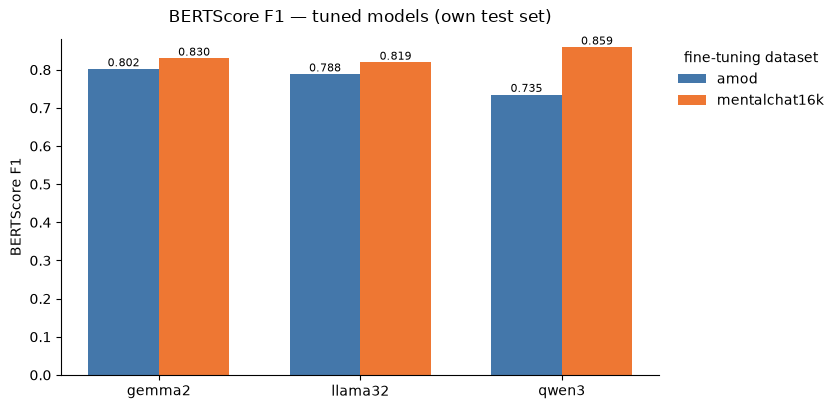

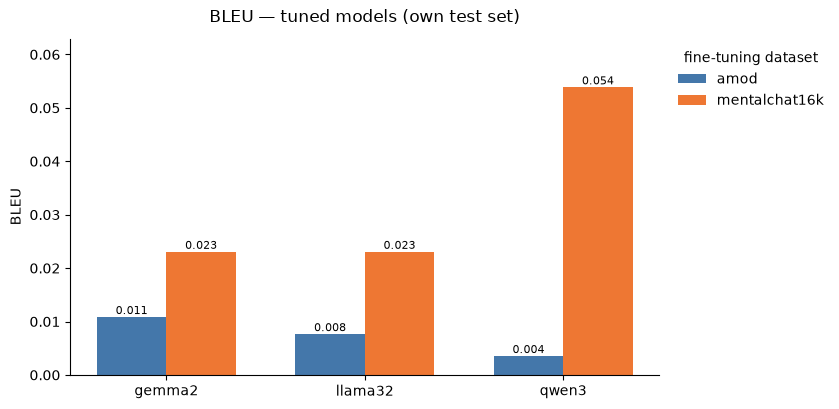

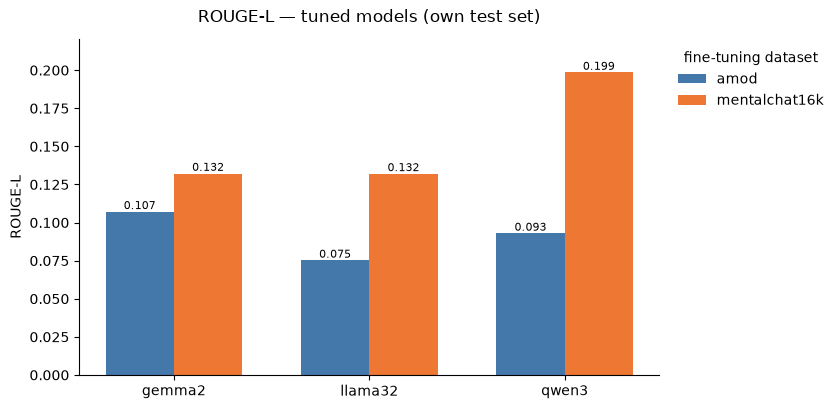

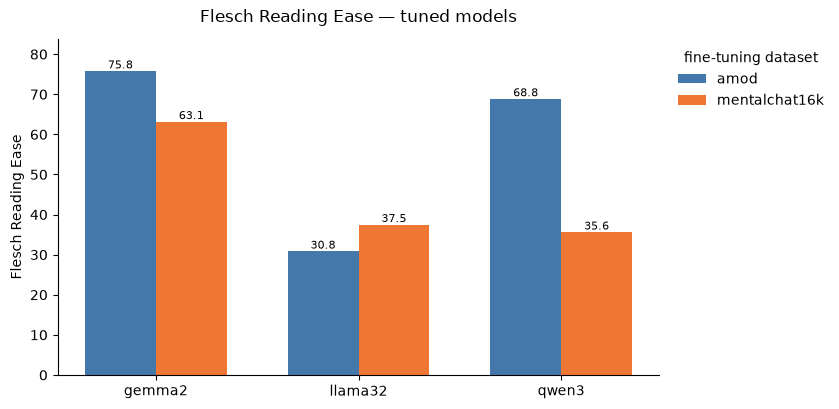

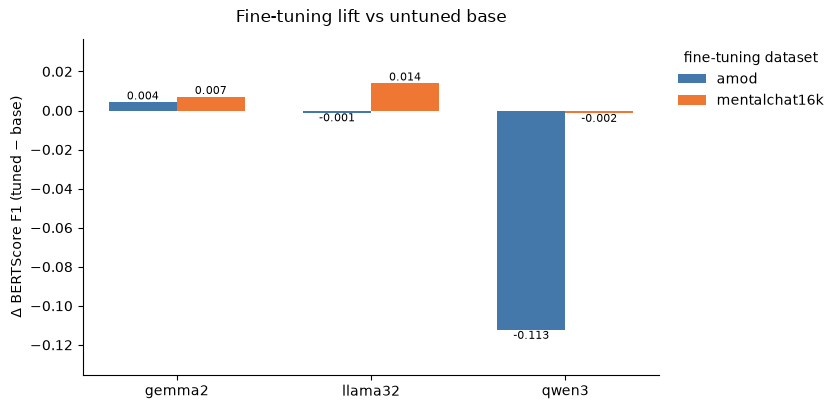

,model,dataset,bertscore_f1_base,bertscore_f1_tuned,delta_bertscore
0,gemma2,amod,0.7977,0.8020,0.0043
1,llama32,amod,0.7896,0.7884,-0.0012
2,qwen3,amod,0.8475,0.7349,-0.1126
3,gemma2,mentalchat16k,0.8228,0.8299,0.0071
4,llama32,mentalchat16k,0.8052,0.8192,0.0140
5,qwen3,mentalchat16k,0.8605,0.8590,-0.0015


In [6]:
# Cell 6 — Charts: models on x, score on y, one bar per dataset
DS_COLORS = {"amod": "#4477AA", "mentalchat16k": "#EE7733"}
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})


def grouped_bars(df, metric, title, fname, fmt="{:.3f}", ylabel=None):
    """One bar per dataset for each model family; legend outside the plot."""
    models = [m for m in MODELS if not df[df["model"] == m].empty]
    x = np.arange(len(models))
    width = 0.35
    plt.figure(figsize=(8.5, 4.2))
    all_vals = []
    for k, ds in enumerate(DATASETS):
        vals = [df[(df["model"] == m) & (df["dataset"] == ds)][metric].mean() for m in models]
        vals = [0 if np.isnan(v) else v for v in vals]
        all_vals += vals
        bars = plt.bar(x + (k - 0.5) * width, vals, width,
                       color=DS_COLORS[ds], label=ds)
        plt.bar_label(bars, fmt=fmt, fontsize=8)
    lo, hi = min(all_vals), max(all_vals)
    span = (hi - lo) or abs(hi) or 1
    plt.ylim(lo - 0.18 * span if lo < 0 else 0,
             hi + 0.18 * span if hi > 0 else 0.05 * span)  # headroom for bar labels
    plt.xticks(x, models)
    plt.ylabel(ylabel or title)
    plt.title(title, fontsize=12, pad=12)
    plt.legend(title="fine-tuning dataset", frameon=False,
               loc="upper left", bbox_to_anchor=(1.01, 1))
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / fname, dpi=150, bbox_inches="tight")
    plt.show()


tuned = scores[scores["variant"] == "tuned"]
grouped_bars(tuned, "bertscore_f1", "BERTScore F1 — tuned models (own test set)",
             "chart_bertscore.png", ylabel="BERTScore F1")
grouped_bars(tuned, "bleu", "BLEU — tuned models (own test set)",
             "chart_bleu.png", ylabel="BLEU")
grouped_bars(tuned, "rouge_l", "ROUGE-L — tuned models (own test set)",
             "chart_rougel.png", ylabel="ROUGE-L")
grouped_bars(tuned, "flesch_reading_ease", "Flesch Reading Ease — tuned models",
             "chart_readability.png", fmt="{:.1f}", ylabel="Flesch Reading Ease")

# Fine-tuning lift: tuned minus base BERTScore on the same test set — the
# fairer signal when comparing across the two datasets.
merged = tuned.merge(scores[scores["variant"] == "base"],
                     on=["model", "dataset"], suffixes=("_tuned", "_base"))
merged["delta_bertscore"] = merged["bertscore_f1_tuned"] - merged["bertscore_f1_base"]
grouped_bars(merged, "delta_bertscore", "Fine-tuning lift vs untuned base",
             "chart_delta_base.png", ylabel="Δ BERTScore F1 (tuned − base)")
merged[["model", "dataset", "bertscore_f1_base", "bertscore_f1_tuned", "delta_bertscore"]]

In [7]:
# Cell 7 — Write results/eval_report.md
lines = ["# Evaluation Report — Counselor Fine-Tuning Study (3 models × 2 datasets)", ""]
lines += ["Each tuned adapter is scored on **its own dataset's held-out test split** "
          "(amod multi-reference), next to the un-tuned base model on the same split.", ""]

lines += ["## Scores", "", scores.to_markdown(index=False), ""]

for ds in DATASETS:
    sub = scores[(scores["dataset"] == ds) & (scores["variant"] == "tuned")]
    if sub.empty:
        continue
    lines += [f"## Winners — {ds} test set", ""]
    for metric in ("bertscore_f1", "bleu", "rouge_l"):
        best = sub.loc[sub[metric].idxmax()]
        lines += [f"- **{metric}**: {best['model']} ({best[metric]})"]
    lines += [""]

if not merged.empty:
    lines += ["## Fine-tuning lift (tuned − base, BERTScore F1, same test set)", "",
              merged[["model", "dataset", "bertscore_f1_base", "bertscore_f1_tuned",
                      "delta_bertscore"]].to_markdown(index=False), ""]

lines += ["## Training manifests", ""]
for ds in DATASETS:
    for mk in MODELS:
        info_path = ft_utils.MODELS_ROOT / ds / mk / "run_info.json"
        if info_path.exists():
            info = json.loads(info_path.read_text(encoding="utf-8"))
            lines += [f"- `{mk}` on `{ds}`: {info.get('train_minutes', '?')} min, "
                      f"final train loss {info.get('final_train_loss')}, "
                      f"best eval loss {info.get('best_eval_loss')}"]
lines += ["", "> ⚠ Raw reference-based scores from the two test sets are not directly "
          "comparable (reference style and length differ between datasets). Use the "
          "per-dataset rankings and the tuned-vs-base Δ for cross-dataset conclusions.", ""]

report_path = RESULTS_DIR / "eval_report.md"
report_path.write_text("\n".join(lines), encoding="utf-8")
print(f"Wrote {report_path}")

Wrote C:\Users\laoli\OneDrive\Desktop\MultiAgent2\fine_tuning_chatbot\results\eval_report.md


## Notes

- **Re-running:** delete a file in `results/predictions/` to regenerate that pass; everything else reuses the cache. Adapters trained after a partial run are picked up automatically on the next run.
- **First metric run** downloads BERTScore's scoring model (roberta-large, ~1.4 GB) once.
- Readability scores are reference-free (computed on the generated replies), so they *are* directly comparable across datasets.